# 02 — Byte-level BPE from scratch

**Phase 2, Part A.** Implement byte-pair encoding (BPE) by hand — the algorithm behind
GPT-2/3/4's tokenizer — to understand it before using the production HF implementation in
notebook 03.

**Papers:**
- Sennrich et al. 2016, *Neural Machine Translation of Rare Words with Subword Units* — BPE
  itself, originally for word-level NMT vocabularies.
- Radford et al. 2019, *Language Models are Unsupervised Multitask Learners* (GPT-2) — the
  **byte-level** variant: operate on raw UTF-8 bytes (256 possible values) instead of
  unicode characters, so there is never an out-of-vocabulary token — any byte sequence is
  representable, even token soup, emoji, or another script.

**Algorithm:** start with the 256 byte values as the vocabulary. Repeatedly count every
adjacent pair of tokens across the corpus, merge the single most frequent pair into a new
token, and repeat until the vocabulary reaches the target size. Encoding replays the same
merges (in the order they were learned) on new text; decoding is just concatenating bytes
and UTF-8-decoding.

Implementation lives in `src/llmlab/tokenizer/bpe_scratch.py` — pure Python, meant for a few
MB of text (one book), not the full corpus.

In [1]:
from pathlib import Path

from llmlab.tokenizer.bpe_scratch import ByteLevelBPE, pretokenize

DATA = Path("../data/clean")
train_text = (DATA / "books" / "marcus-aurelius-meditations.txt").read_text()
# held out of THIS scratch-BPE's training set (also globally held out of the whole project,
# per PROGRESS.md's val split) — used below to check compression on unseen text.
held_out_text = (DATA / "val" / "books" / "boethius-the-consolation-of-philosophy.txt").read_text()

print(f"train book: {len(train_text):,} chars, {len(train_text.encode()):,} bytes")
print(f"held-out book: {len(held_out_text):,} chars, {len(held_out_text.encode()):,} bytes")

train book: 398,138 chars, 398,619 bytes
held-out book: 244,659 chars, 244,685 bytes


## Toy example: pre-tokenization matters

Before training on a real book, look at how the three pre-tokenization modes chunk a toy
sentence. Chunks are the boundaries merges are *not allowed* to cross.

In [2]:
toy = "the cat sat. the cat ran fast!"
for mode in ["none", "whitespace", "gpt2"]:
    print(f"{mode:12s}: {pretokenize(toy, mode)}")

none        : ['the cat sat. the cat ran fast!']
whitespace  : ['the', 'cat', 'sat.', 'the', 'cat', 'ran', 'fast!']
gpt2        : ['the', ' cat', ' sat', '.', ' the', ' cat', ' ran', ' fast', '!']


`none` treats the whole string as one chunk, so nothing stops a merge from gluing `"t."` or
`"n f"` together — punctuation and word boundaries are invisible to it. `whitespace` at least
keeps words apart, but punctuation stays glued to its neighbor (`"sat."`, `"fast!"`). `gpt2`'s
regex separates letters, digits, and punctuation runs, and treats a leading space as part of
the *next* word (` cat` is one chunk) — this is why GPT-2-family models produce a token like
`" the"` that's different from `"the"` at the start of a chunk. We'll see below how this
changes the merges a real training run learns.

## Train on one book, watch the first merges emerge

Train a `gpt2`-pretokenized BPE on the Meditations text. `verbose=True` prints the first 20
merges — watch letters combine into common substrings, then whole short words.

In [3]:
tok = ByteLevelBPE(pretok_mode="gpt2")
merge_log = tok.train(train_text, vocab_size=2000, verbose=True)
print(f"\nlearned {len(merge_log)} merges, final vocab size {tok.vocab_size}")

merge    0: b't' + b'h' -> b'th'  (freq=12564)


merge    1: b' ' + b'th' -> b' th'  (freq=8697)


merge    2: b' ' + b'a' -> b' a'  (freq=8491)


merge    3: b'e' + b'r' -> b'er'  (freq=5425)
merge    4: b'i' + b'n' -> b'in'  (freq=5348)


merge    5: b' ' + b'o' -> b' o'  (freq=4712)


merge    6: b'n' + b'd' -> b'nd'  (freq=4214)
merge    7: b'a' + b't' -> b'at'  (freq=4180)
merge    8: b' ' + b'w' -> b' w'  (freq=3949)


merge    9: b' th' + b'e' -> b' the'  (freq=3841)
merge   10: b' ' + b's' -> b' s'  (freq=3453)
merge   11: b'r' + b'e' -> b're'  (freq=3409)
merge   12: b'o' + b'n' -> b'on'  (freq=3140)


merge   13: b'i' + b's' -> b'is'  (freq=3053)
merge   14: b' ' + b'b' -> b' b'  (freq=2993)
merge   15: b't' + b'o' -> b'to'  (freq=2897)
merge   16: b' a' + b'nd' -> b' and'  (freq=2893)


merge   17: b' ' + b'h' -> b' h'  (freq=2819)
merge   18: b' ' + b'm' -> b' m'  (freq=2766)
merge   19: b'o' + b'u' -> b'ou'  (freq=2589)



learned 1744 merges, final vocab size 2000


The very first merges are near-universal English bigrams (`t`+`h` -> `th`, `th`+`e` ->
`the`) — these are frequent in *any* English text, not specific to Marcus Aurelius. A few
merges in, whole short words appear as single tokens (`the`, `and`, `of`) because pretokenization
already isolated them at chunk boundaries, so once the letters are glued the merge count can't
be beaten by anything crossing into the next word. This is the compounding nature of BPE:
each merge changes the pair-frequency landscape for the next one.

## Encode / decode round-trip

Byte-level BPE can never hit an unknown token: any string encodes to *some* sequence of byte
IDs (falling back to raw bytes wherever no merge applies), and decoding is lossless. Verify
this on both the training text and the held-out book (never seen during training).

In [4]:
for name, text in [("train (seen)", train_text[:5000]), ("held-out (unseen)", held_out_text[:5000])]:
    ids = tok.encode(text)
    decoded = tok.decode(ids)
    ratio = len(text.encode()) / len(ids)
    print(f"{name:20s}: {len(ids):5d} tokens for {len(text.encode()):5d} bytes "
          f"({ratio:.2f} bytes/token) — roundtrip {'OK' if decoded == text else 'FAILED'}")

train (seen)        :  1786 tokens for  5000 bytes (2.80 bytes/token) — roundtrip OK
held-out (unseen)   :  2073 tokens for  5009 bytes (2.42 bytes/token) — roundtrip OK


In [5]:
# Round-trip on genuinely out-of-distribution input: emoji, another script, code-like symbols.
weird = "hello \U0001F600 world \u4e2d\u6587 <tag attr=\"x\"/> 42.0%"
weird_ids = tok.encode(weird)
print(weird_ids)
print("roundtrip OK:", tok.decode(weird_ids) == weird)

[646, 290, 111, 32, 240, 159, 152, 128, 491, 32, 228, 184, 173, 230, 150, 135, 32, 60, 116, 719, 1854, 114, 61, 34, 120, 34, 47, 62, 32, 52, 50, 46, 48, 37]
roundtrip OK: True


This is the point of byte-level BPE: none of `😀`, `中文`, or `<tag attr="x"/>` appeared
anywhere in the training book, yet every one of them round-trips exactly, because the base
vocabulary is *all 256 byte values*, not a fixed set of characters or words. A word-level or
character-only tokenizer would need an `<unk>` token here; byte-level BPE never does.

## Does pre-tokenization change what gets learned?

Train three tokenizers on the same text and vocab size, one per pre-tokenization mode, and
compare: how many learned merges span what *would* be a word/whitespace boundary under
`gpt2` rules (a proxy for "the merge glues unrelated words together")?

In [6]:
VOCAB_FOR_COMPARISON = 1000
# small sample: with pretok_mode="none" the WHOLE input is one chunk, and this from-scratch
# encode() is pure Python (O(chunk length) per merge applied) — fine for a paragraph, far
# too slow for a whole book.
compare_sample = held_out_text[:20_000]

variants = {}
for mode in ["none", "whitespace", "gpt2"]:
    t = ByteLevelBPE(pretok_mode=mode)
    log = t.train(train_text, vocab_size=VOCAB_FOR_COMPARISON)
    variants[mode] = (t, log)

for mode, (t, log) in variants.items():
    ids = t.encode(compare_sample)
    ratio = len(compare_sample.encode()) / len(ids)
    # crude cross-boundary check: does the merged bytes chunk contain an internal space
    # NOT at its start (i.e. glues two words together rather than "space + word")?
    crossing = sum(1 for e in log if b" " in e["bytes"][1:])
    print(f"{mode:12s}: {ratio:.2f} bytes/token on held-out sample, "
          f"{crossing}/{len(log)} merges glue words across a space")

none        : 2.14 bytes/token on held-out sample, 296/744 merges glue words across a space
whitespace  : 2.36 bytes/token on held-out sample, 0/744 merges glue words across a space
gpt2        : 2.16 bytes/token on held-out sample, 0/744 merges glue words across a space


`none` (whole-text chunking) learns merges that splice the end of one word onto the start of
the next, purely because that particular collision happened to be frequent in this specific
book — those merges are useless on any other text. `whitespace` and `gpt2` both confine
merges to single words (plus, for `gpt2`, an attached leading space), which is why production
BPE tokenizers always pre-tokenize: it keeps every learned merge *linguistically meaningful*
rather than an artifact of one training corpus, which is exactly what generalizes to unseen
text.

## Vocab size vs. compression

Train once to a large vocab, then measure compression on the held-out book at several
intermediate vocab sizes by replaying only the first *k* merges (merges are learned in a
fixed order, so vocab size *v* is exactly "the first *v* − 256 merges" — no retraining
needed per point).

In [7]:
from llmlab.tokenizer.bpe_scratch import ByteLevelBPE as _BPE

MAX_VOCAB = 8000
full = ByteLevelBPE(pretok_mode="gpt2")
full_log = full.train(train_text, vocab_size=MAX_VOCAB)

checkpoints = [256, 500, 1000, 2000, 3000, 4000, 6000, 8000]
sample_text = held_out_text[:50_000]  # one "page"-scale sample, fixed across checkpoints
sample_bytes = len(sample_text.encode())

results = []
all_merges = list(full.merges.items())
for v in checkpoints:
    k = v - 256
    partial = _BPE(pretok_mode="gpt2", merges=dict(all_merges[:k]))
    n_tokens = len(partial.encode(sample_text))
    results.append((v, n_tokens, sample_bytes / n_tokens))
    print(f"vocab={v:5d}: {n_tokens:5d} tokens ({sample_bytes/n_tokens:.2f} bytes/token)")

vocab=  256: 50010 tokens (1.00 bytes/token)
vocab=  500: 25872 tokens (1.93 bytes/token)
vocab= 1000: 21048 tokens (2.38 bytes/token)
vocab= 2000: 18374 tokens (2.72 bytes/token)
vocab= 3000: 17298 tokens (2.89 bytes/token)


vocab= 4000: 16593 tokens (3.01 bytes/token)
vocab= 6000: 15809 tokens (3.16 bytes/token)
vocab= 8000: 15328 tokens (3.26 bytes/token)


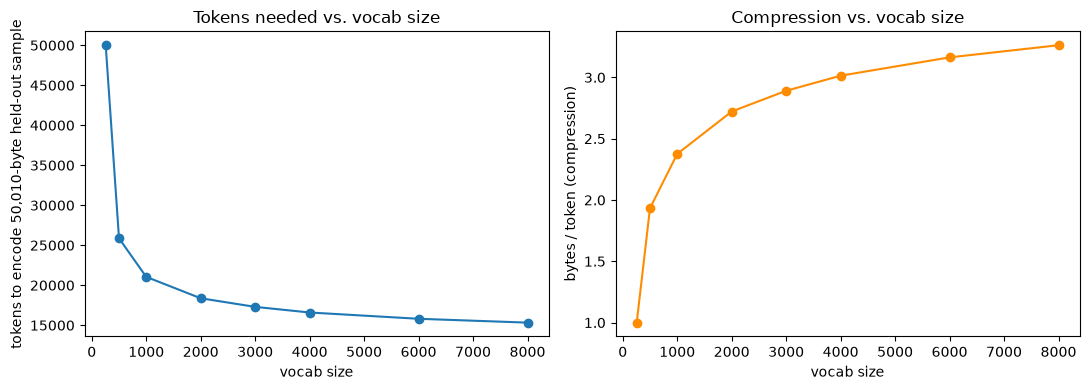

In [8]:
import matplotlib.pyplot as plt

vocabs, ntoks, ratios = zip(*results)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(vocabs, ntoks, marker="o")
ax[0].set_xlabel("vocab size")
ax[0].set_ylabel(f"tokens to encode {sample_bytes:,}-byte held-out sample")
ax[0].set_title("Tokens needed vs. vocab size")

ax[1].plot(vocabs, ratios, marker="o", color="darkorange")
ax[1].set_xlabel("vocab size")
ax[1].set_ylabel("bytes / token (compression)")
ax[1].set_title("Compression vs. vocab size")
fig.tight_layout()
plt.show()

Compression improves fast at first (each new merge captures a common pattern) and then
flattens — diminishing returns as the remaining frequent patterns run out in a corpus this
small (one book). This is the shape behind the vocab-size trade-off explored properly in
notebook 03 on the *full* corpus with the production HF tokenizer: bigger vocab -> fewer
tokens per text (shorter sequences, more effective context) but a bigger embedding table and
rarer tokens seen less often during training.

## Learning checkpoints

- Walk through 2-3 BPE merge steps on paper for a toy string (e.g. `"aaabdaaabac"`) and check
  it matches what `train()` learns.
- Why does byte-level BPE never produce an out-of-vocabulary token, unlike word-level or
  even standard character-level tokenizers restricted to a fixed alphabet?
- Why does pre-tokenization (none vs. whitespace vs. GPT-2 regex) change which merges get
  learned, and why does that matter for generalizing to unseen text?